# PJM LMP Explorer
Exploration and verification of ingested PJM data.
Run cells top-to-bottom after running the ingest scripts.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine
from config import DB, ZONES, HUBS

url = (f"postgresql+psycopg2://{DB['user']}:{DB['password']}"
       f"@{DB['host']}:{DB['port']}/{DB['dbname']}")
engine = create_engine(url)
conn = engine.connect()
print('Connected to', DB['dbname'])

Connected to pjm_pipeline


## 1. Row counts — verify ingest

In [2]:
ts_tables = ['pjm_da_lmp', 'pjm_rt_lmp', 'pjm_load_metered', 'pjm_gen_by_fuel']

for t in ts_tables:
    df = pd.read_sql(f"""SELECT COUNT(*) AS n,
                              MIN(datetime_beginning_utc) AS first,
                              MAX(datetime_beginning_utc) AS last FROM {t}""", conn)
    print(f'{t:30s}  rows={df.n[0]:>10,}  {df.first[0]} → {df.last[0]}')

df = pd.read_sql("SELECT COUNT(*) AS n FROM pjm_pnodes", conn)
print(f'{"pjm_pnodes":30s}  rows={df.n[0]:>10,}  (no timestamp column)')

pjm_da_lmp                      rows= 1,381,590  2022-01-01 11:00:00+00:00 → 2026-07-06 08:00:00+00:00
pjm_rt_lmp                      rows= 1,379,070  2022-01-01 11:00:00+00:00 → 2026-07-02 08:00:00+00:00
pjm_load_metered                rows= 1,182,060  2022-01-01 11:00:00+00:00 → 2026-07-02 08:00:00+00:00
pjm_gen_by_fuel                 rows=   404,511  2022-01-01 11:00:00+00:00 → 2026-07-06 08:00:00+00:00
pjm_pnodes                      rows=    21,237  (no timestamp column)


## 2. DA LMP — zone comparison

In [3]:
zones_str = ', '.join(f"'{z}'" for z in ZONES)

da_lmp = pd.read_sql(f"""
    SELECT
        datetime_beginning_utc::date   AS day,
        pnode_name,
        AVG(lmp)                       AS avg_lmp,
        AVG(congestion_price)          AS avg_cong
    FROM pjm_da_lmp
    WHERE pnode_name IN ({zones_str})
    GROUP BY 1, 2
    ORDER BY 1, 2
""", conn, parse_dates=['day'])

da_pivot = da_lmp.pivot(index='day', columns='pnode_name', values='avg_lmp')
da_pivot.tail().style.format("{:.2f}", na_rep="-")

pnode_name,AEP,COMED,DOM,PECO
day,,,,
2026-07-02 00:00:00,260.26,231.77,375.52,288.70
2026-07-03 00:00:00,164.62,120.85,343.57,243.05
2026-07-04 00:00:00,147.92,101.57,310.67,176.74
2026-07-05 00:00:00,44.83,37.55,82.65,41.50
2026-07-06 00:00:00,55.24,52.12,86.53,42.51


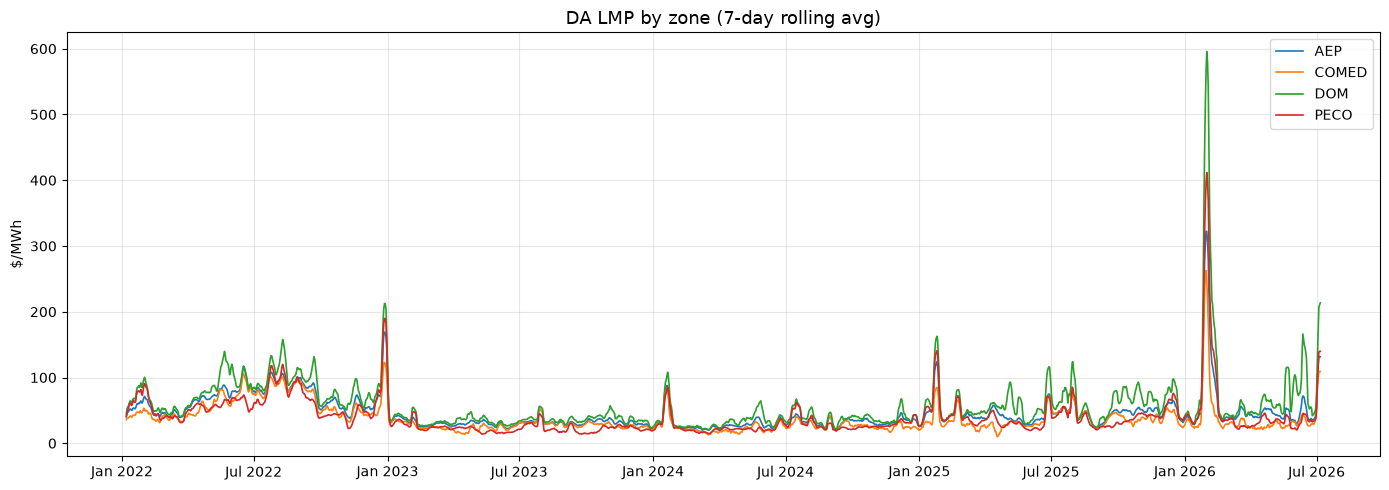

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
for zone in da_pivot.columns:
    ax.plot(da_pivot.index, da_pivot[zone].rolling(7).mean(), label=zone, linewidth=1.2)

ax.set_title('DA LMP by zone (7-day rolling avg)', fontsize=13)
ax.set_ylabel('$/MWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. DA vs RT spread (DOM zone)

In [5]:
spread = pd.read_sql("""
    SELECT
        d.datetime_beginning_utc AS hour,
        d.lmp AS da_lmp,
        r.lmp AS rt_lmp,
        (r.lmp - d.lmp) AS spread
    FROM pjm_da_lmp d
    JOIN pjm_rt_lmp r
        ON d.datetime_beginning_utc = r.datetime_beginning_utc
       AND d.pnode_name             = r.pnode_name
    WHERE d.pnode_name = 'DOM'
    ORDER BY 1
""", conn, parse_dates=['hour'])

print(f"Rows: {len(spread):,}")
spread.describe()

Rows: 39,402


,da_lmp,rt_lmp,spread
count,39402.000000,39402.000000,39402.000000
mean,58.259135,60.249416,1.990280
std,65.342122,102.295013,81.083789
min,9.658600,-41.840400,-1075.259900
25%,28.924500,25.529050,-10.274075
50%,41.456500,37.261700,-3.507600
75%,64.652675,59.714700,2.143950
max,1877.355100,4392.119700,3977.226600


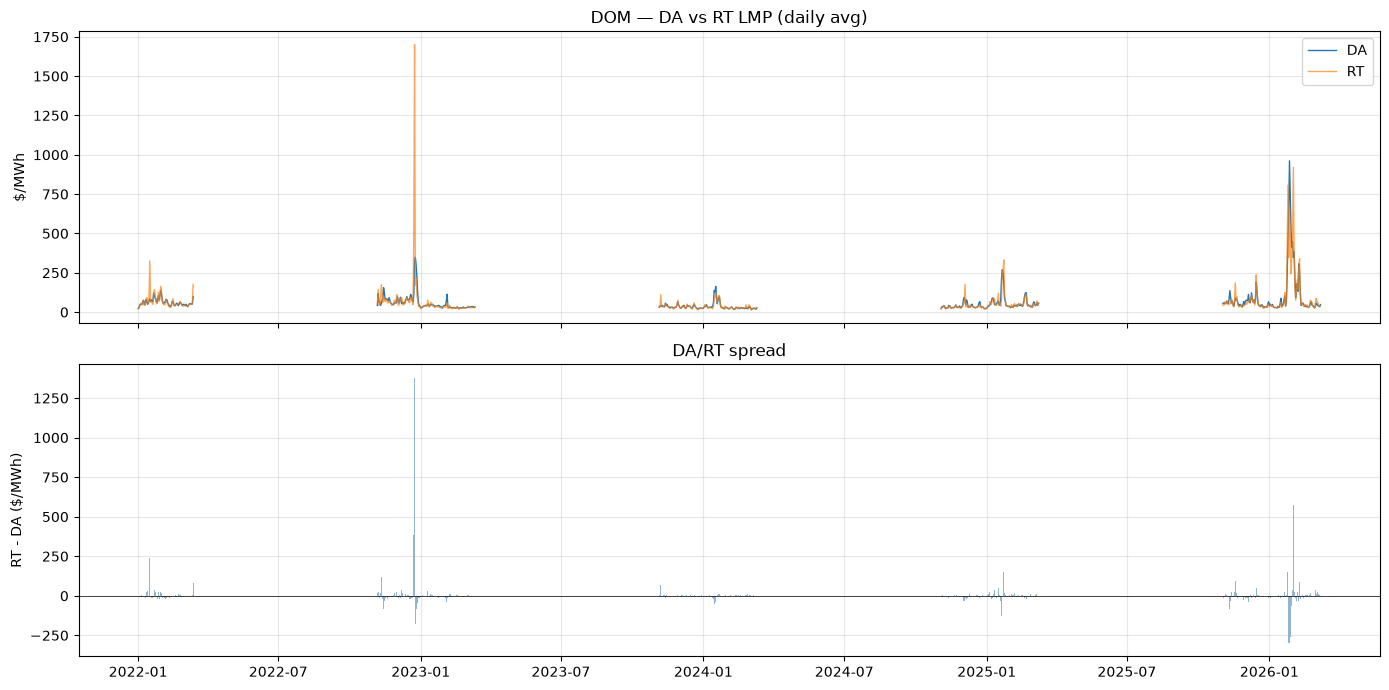

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

daily = spread.set_index('hour').resample('D').mean()

axes[0].plot(daily.index, daily['da_lmp'], label='DA', linewidth=1)
axes[0].plot(daily.index, daily['rt_lmp'], label='RT', linewidth=1, alpha=0.7)
axes[0].set_ylabel('$/MWh')
axes[0].set_title('DOM — DA vs RT LMP (daily avg)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(daily.index, daily['spread'], width=1, color='steelblue', alpha=0.6)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('RT - DA ($/MWh)')
axes[1].set_title('DA/RT spread')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Congestion analysis — which zones are most congested?

In [7]:
cong = pd.read_sql(f"""
    SELECT
        pnode_name,
        AVG(ABS(congestion_price))   AS avg_abs_congestion,
        STDDEV(congestion_price)     AS stddev_congestion,
        AVG(lmp)                     AS avg_lmp,
        COUNT(*)                     AS hours
    FROM pjm_da_lmp
    WHERE pnode_name IN ({zones_str})
    GROUP BY 1
    ORDER BY 2 DESC
""", conn)
cong

,pnode_name,avg_abs_congestion,stddev_congestion,avg_lmp,hours
0,DOM,10.112956,26.381208,58.639284,39474
1,PECO,8.346273,14.176204,40.498864,39474
2,COMED,8.207901,18.379923,37.849774,39474
3,AEP,3.186171,9.851729,46.366924,39474


## 5. Generation fuel mix

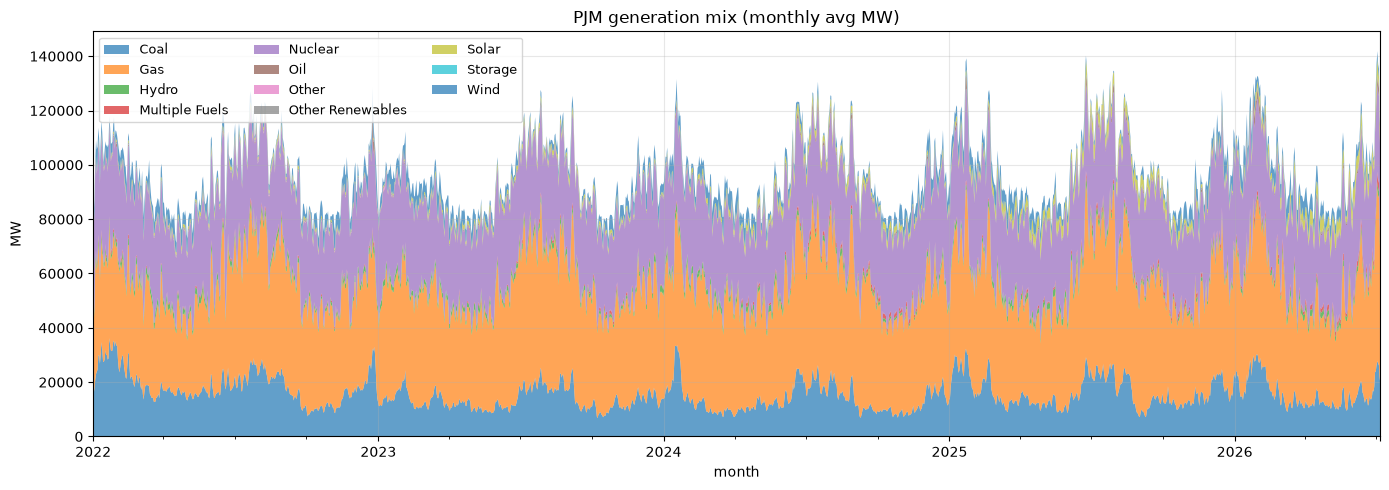

In [8]:
gen = pd.read_sql("""
    SELECT
        datetime_beginning_utc::date   AS month,
        fuel_type,
        AVG(mw)                        AS avg_mw
    FROM pjm_gen_by_fuel
    GROUP BY 1, 2
    ORDER BY 1, 2
""", conn, parse_dates=['month'])

gen_pivot = gen.pivot(index='month', columns='fuel_type', values='avg_mw').fillna(0)

fig, ax = plt.subplots(figsize=(14, 5))
gen_pivot.plot.area(ax=ax, alpha=0.7, linewidth=0)
ax.set_title('PJM generation mix (monthly avg MW)')
ax.set_ylabel('MW')
ax.legend(loc='upper left', ncol=3, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. DOM zone — LMP vs load (datacenter signal)

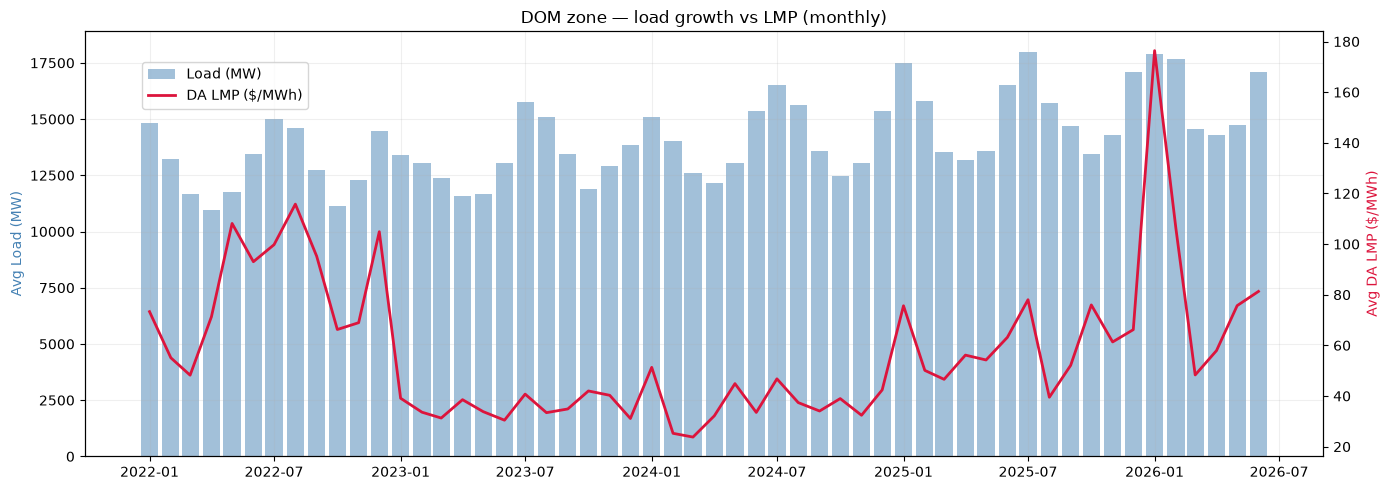

In [9]:
dom_load = pd.read_sql("""
    SELECT
        date_trunc('month', l.datetime_beginning_utc)::date AS month,
        AVG(l.mw)   AS avg_load_mw,
        AVG(d.lmp)  AS avg_lmp
    FROM pjm_load_metered l
    JOIN pjm_da_lmp d
        ON l.datetime_beginning_utc = d.datetime_beginning_utc
       AND d.pnode_name = 'DOM'
    WHERE l.area = 'DOM'
    GROUP BY 1
    ORDER BY 1
""", conn, parse_dates=['month'])

last_complete_month = pd.Timestamp.now().normalize().replace(day=1)
dom_load = dom_load[dom_load['month'] < last_complete_month]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(dom_load['month'], dom_load['avg_load_mw'], width=25,
        color='steelblue', alpha=0.5, label='Load (MW)')
ax2.plot(dom_load['month'], dom_load['avg_lmp'],
         color='crimson', linewidth=2, label='DA LMP ($/MWh)')

ax1.set_ylabel('Avg Load (MW)', color='steelblue')
ax2.set_ylabel('Avg DA LMP ($/MWh)', color='crimson')
ax1.set_title('DOM zone — load growth vs LMP (monthly)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
ax1.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 7. Monthly DA vs RT LMP by peak period — pnode explorer

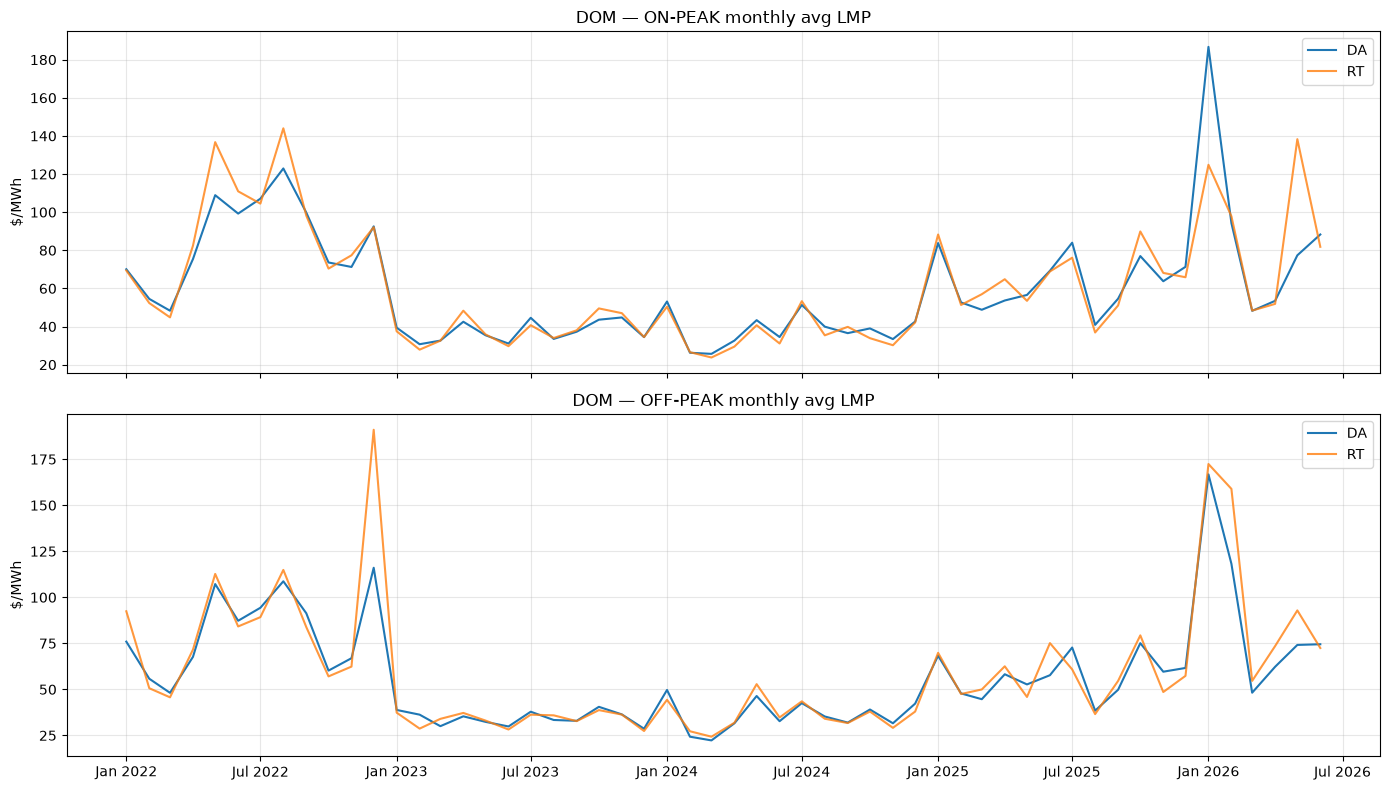

In [10]:
pnode_name = 'DOM'

peak = pd.read_sql(
    "SELECT * FROM pjm_lmp_monthly_peak(%(pnode)s)",
    conn, params={'pnode': pnode_name}, parse_dates=['month_start']
)

last_complete_month = pd.Timestamp.now().normalize().replace(day=1)
peak = peak[peak['month_start'] < last_complete_month]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, ptype in zip(axes, ['ON-PEAK', 'OFF-PEAK']):
    sub = peak[peak['peak_type'] == ptype].set_index('month_start')
    ax.plot(sub.index, sub['avg_da_lmp'], label='DA', linewidth=1.5)
    ax.plot(sub.index, sub['avg_rt_lmp'], label='RT', linewidth=1.5, alpha=0.8)
    ax.set_title(f'{pnode_name} — {ptype} monthly avg LMP')
    ax.set_ylabel('$/MWh')
    ax.legend()
    ax.grid(alpha=0.3)

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.show()

In [11]:
conn.close()
engine.dispose()
print('Done.')

Done.
